# Test Composite Cross Section Calculations

This notebook tests the automatic computation of composite cross sections (MT 4, 18, 101, etc.) from their component reactions.

In [1]:
import sys
sys.path.insert(0, r'C:\Users\Usuario\BaradDur\Dev\kika')

import numpy as np
import matplotlib.pyplot as plt
from kika.ace.parsers import read_ace
from kika._constants import MT_COMPOSITES, MT_COMPOSITE_ORDER, MT_TO_REACTION
from kika.plotting import PlotBuilder

## Load ACE File (Fe-56)

In [2]:
ace_file = r'c:\Users\Usuario\BaradDur\Dev\kika\files\ace\260560_80.02c'
ace = read_ace(ace_file)
print(f"Loaded: {ace.zaid}")
print(f"Available MT numbers: {ace.mt_numbers}")

Loaded: 26056
Available MT numbers: [1, 2, 5, 16, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 101, 102, 103, 107, 111, 203, 204, 205, 206, 207, 444, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 649, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818]


## Test 1: Check MT_COMPOSITES Definitions

In [3]:
print("Composite MT Definitions:")
print("=" * 60)
for mt in MT_COMPOSITE_ORDER:
    if mt in MT_COMPOSITES:
        components, description = MT_COMPOSITES[mt]
        print(f"MT {mt:3d}: {description}")

Composite MT Definitions:
MT   4: Total inelastic = MT 50-91
MT  16: Total (n,2n) = MT 875-891
MT  18: Total fission = first + second + third + fourth chance
MT 103: Total (n,p)
MT 104: Total (n,d)
MT 105: Total (n,t)
MT 106: Total (n,3He)
MT 107: Total (n,alpha)
MT 101: Neutron disappearance = MT 102-117, 155, 182, 191-193, 197
MT  27: Total absorption = fission + disappearance
MT   3: Non-elastic
MT   1: Total = elastic + non-elastic


## Test 2: Get Composite Info for Each MT

In [4]:
print("Composite Info for Each MT:")
print("=" * 80)
for mt in [4, 18, 27, 101, 103, 107, 1, 3]:
    info = ace.cross_section.get_composite_info(mt)
    print(f"\nMT {mt}:")
    print(f"  Is composite: {info['is_composite']}")
    if info['is_composite']:
        print(f"  Description: {info['description']}")
        print(f"  Can compute: {info['can_compute']}")
        print(f"  Is complete: {info['is_complete']}")
        print(f"  Available components: {len(info['available_components'])} of {len(info['components'])}")
        if info['missing_components']:
            missing_sample = info['missing_components'][:10]
            print(f"  Missing (first 10): {missing_sample}")

Composite Info for Each MT:

MT 4:
  Is composite: True
  Description: Total inelastic = MT 50-91
  Can compute: True
  Is complete: False
  Available components: 40 of 42
  Missing (first 10): [50, 90]

MT 18:
  Is composite: True
  Description: Total fission = first + second + third + fourth chance
  Can compute: False
  Is complete: False
  Available components: 0 of 4
  Missing (first 10): [19, 20, 21, 38]

MT 27:
  Is composite: True
  Description: Total absorption = fission + disappearance
  Can compute: True
  Is complete: False
  Available components: 1 of 2
  Missing (first 10): [18]

MT 101:
  Is composite: True
  Description: Neutron disappearance = MT 102-117, 155, 182, 191-193, 197
  Can compute: True
  Is complete: False
  Available components: 4 of 22
  Missing (first 10): [104, 105, 106, 108, 109, 110, 112, 113, 114, 115]

MT 103:
  Is composite: True
  Description: Total (n,p)
  Can compute: True
  Is complete: False
  Available components: 11 of 50
  Missing (first 10

## Test 3: Compute MT 4 (Total Inelastic) from Components

In [5]:
# Check which inelastic levels are available
inelastic_mts = [mt for mt in ace.mt_numbers if 50 <= mt <= 91]
print(f"Available inelastic levels: {inelastic_mts}")

# Get MT 4 (should be computed from components)
mt4_info = ace.cross_section.get_composite_info(4)
print(f"\nMT 4 can be computed: {mt4_info['can_compute']}")

if mt4_info['can_compute']:
    mt4 = ace.cross_section._get_or_compute_reaction(4)
    print(f"MT 4 computed successfully: {mt4 is not None}")
    if mt4:
        print(f"  Energy range: {mt4.energies[0]:.4e} - {mt4.energies[-1]:.4e} MeV")
        print(f"  Number of points: {len(mt4.energies)}")

Available inelastic levels: [51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91]

MT 4 can be computed: True
MT 4 computed successfully: True
  Energy range: 1.0000e-11 - 1.5000e+02 MeV
  Number of points: 42087


## Test 4: Plot MT 4 vs Individual Inelastic Levels (Using PlotBuilder)

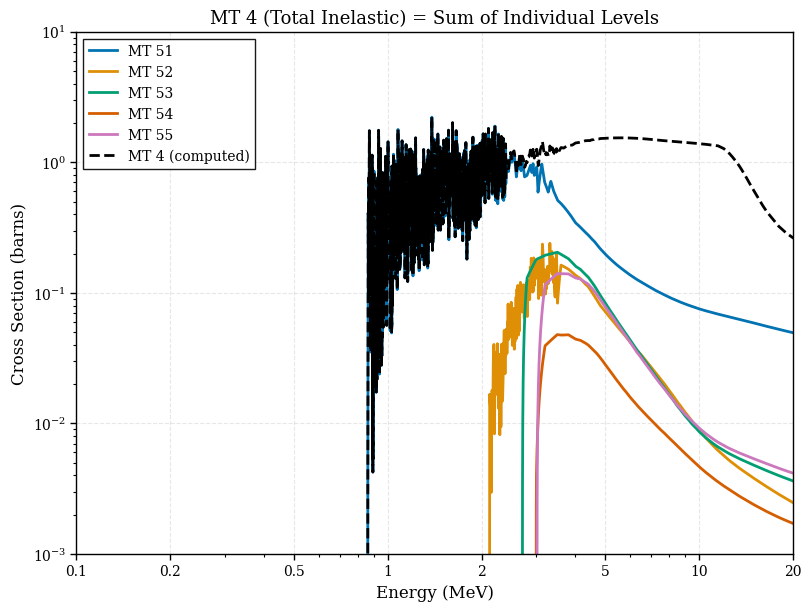

In [17]:
# Plot using PlotBuilder
builder = PlotBuilder()

# Add individual inelastic levels
for mt in inelastic_mts[:5]:  # Plot first 5 levels
    try:
        builder.add_data(ace.cross_section.to_plot_data(mt, label=f'MT {mt}'))
    except ValueError:
        pass

# Add computed MT 4
if mt4_info['can_compute']:
    builder.add_data(ace.cross_section.to_plot_data(4, label='MT 4 (computed)', linestyle='--', linewidth=2, color='black'))

# Configure plot
builder.set_scales(log_x=True, log_y=True)
builder.set_labels(x_label='Energy (MeV)', y_label='Cross Section (barns)', title='MT 4 (Total Inelastic) = Sum of Individual Levels')
builder.set_limits(x_lim=(0.1,20), y_lim=(1e-3, 1e1))

# Build and show
fig = builder.build()
plt.show()

## Test 5: Verify Sum Calculation

In [18]:
# Manually compute sum of inelastic levels and compare with computed MT 4
if mt4_info['can_compute']:
    mt4 = ace.cross_section._get_or_compute_reaction(4)
    
    # Get full energy grid
    energy_grid = ace.cross_section.energy_grid
    num_energies = len(energy_grid)
    
    # Manual sum
    manual_sum = np.zeros(num_energies)
    for mt in range(50, 92):
        rx = ace.cross_section.reaction.get(mt)
        if rx:
            start_idx = rx.energy_idx
            for i, val in enumerate(rx.xs_values):
                grid_idx = start_idx + i
                if 0 <= grid_idx < num_energies:
                    manual_sum[grid_idx] += val
    
    # Compare
    computed_sum = np.array(mt4.xs_values)
    
    # Check difference
    max_diff = np.max(np.abs(computed_sum - manual_sum))
    rel_diff = np.max(np.abs(computed_sum - manual_sum) / (manual_sum + 1e-30))
    
    print(f"Maximum absolute difference: {max_diff:.2e}")
    print(f"Maximum relative difference: {rel_diff:.2e}")
    print(f"Sums match: {np.allclose(computed_sum, manual_sum)}")

Maximum absolute difference: 0.00e+00
Maximum relative difference: 0.00e+00
Sums match: True


## Test 6: Test Caching

In [19]:
# Clear cache
ace.cross_section.clear_composite_cache()
print(f"Cache after clear: {getattr(ace.cross_section, '_composite_cache', {})}")

# Get MT 4 - should compute and cache
mt4_first = ace.cross_section._get_or_compute_reaction(4)
print(f"MT 4 in cache: {4 in ace.cross_section._composite_cache}")

# Get MT 4 again - should return from cache (same object)
mt4_second = ace.cross_section._get_or_compute_reaction(4)
print(f"Same object from cache: {mt4_first is mt4_second}")

Cache after clear: {}
MT 4 in cache: True
Same object from cache: True


## Test 7: Test MT 101 (Neutron Disappearance)

In [20]:
mt101_info = ace.cross_section.get_composite_info(101)
print(f"MT 101 (Neutron Disappearance):")
print(f"  Description: {mt101_info['description']}")
print(f"  Can compute: {mt101_info['can_compute']}")
print(f"  Available: {mt101_info['available_components'][:10]}...")
print(f"  Missing: {mt101_info['missing_components'][:10]}...")

# MT 101 is typically stored directly in ACE files
if 101 in ace.cross_section.reaction:
    print("\nMT 101 is directly available in ACE file (stored in ESZ block)")
    mt101_stored = ace.cross_section.reaction[101]
    print(f"  Energy range: {mt101_stored.energies[0]:.4e} - {mt101_stored.energies[-1]:.4e} MeV")

MT 101 (Neutron Disappearance):
  Description: Neutron disappearance = MT 102-117, 155, 182, 191-193, 197
  Can compute: True
  Available: [102, 103, 107, 111]...
  Missing: [104, 105, 106, 108, 109, 110, 112, 113, 114, 115]...

MT 101 is directly available in ACE file (stored in ESZ block)
  Energy range: 1.0000e-11 - 1.5000e+02 MeV


## Test 8: Plot Multiple Composite Cross Sections (Using PlotBuilder)

C:\Users\Usuario\BaradDur\Dev\kika\kika\plotting\plot_builder.py:1731: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  self.ax.set_ylim(y_min, y_max)


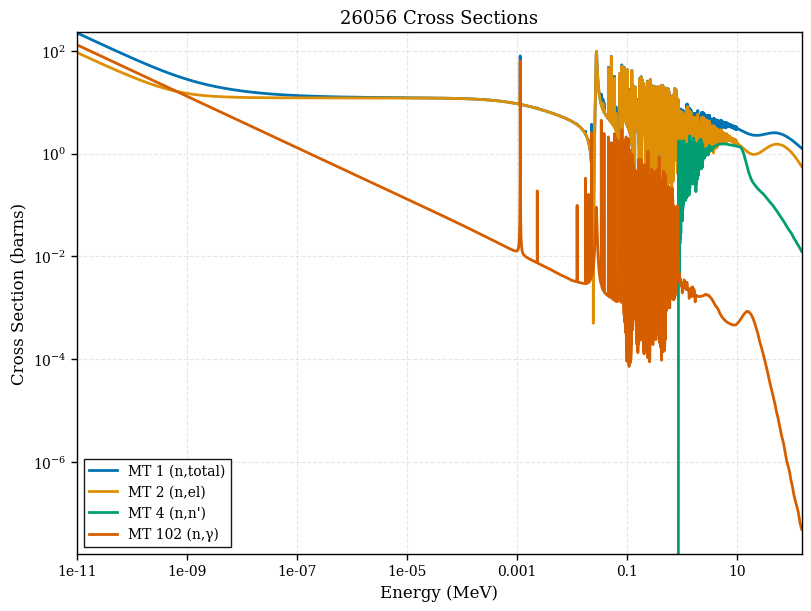

In [21]:
# Plot standard cross sections using PlotBuilder
builder = PlotBuilder()

for mt in [1, 2, 4, 102]:
    try:
        reaction_name = MT_TO_REACTION.get(mt, f'MT {mt}')
        builder.add_data(ace.cross_section.to_plot_data(mt, label=f'MT {mt} {reaction_name}'))
    except ValueError:
        pass

builder.set_scales(log_x=True, log_y=True)
builder.set_labels(
    x_label='Energy (MeV)', 
    y_label='Cross Section (barns)', 
    title=f'{ace.zaid} Cross Sections'
)

fig = builder.build()
plt.show()

## Test 9: Compare Legacy plot() and PlotBuilder

C:\Users\Usuario\AppData\Local\Temp\ipykernel_49336\1021535490.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


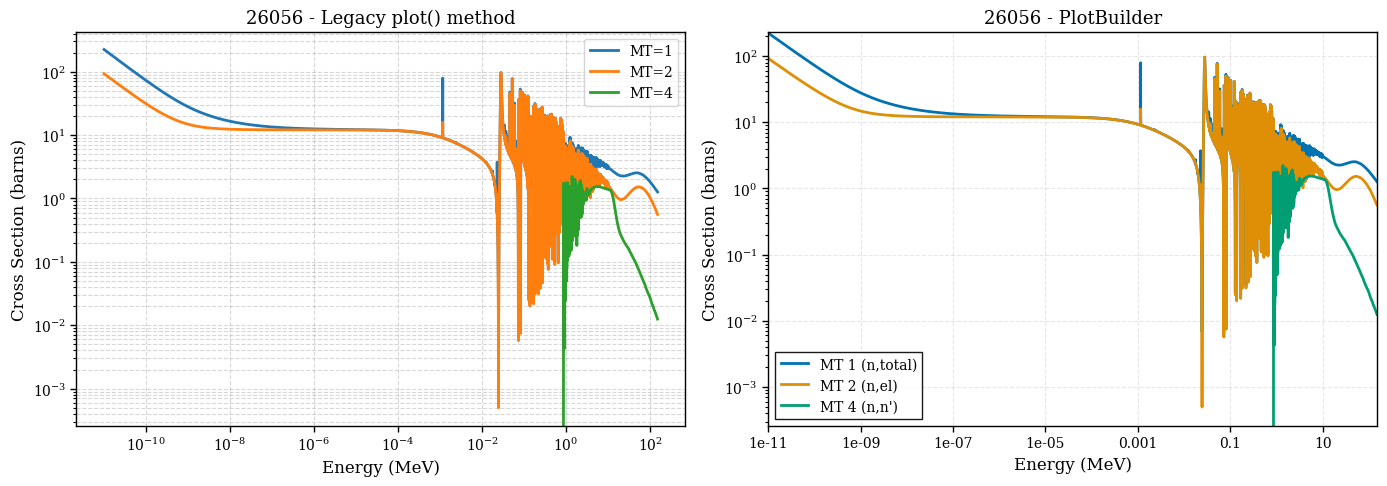

In [22]:
# Compare legacy plot() method and PlotBuilder

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legacy approach: using plot() method directly
ace.cross_section.plot([1, 2, 4], ax=axes[0])
axes[0].set_title(f'{ace.zaid} - Legacy plot() method')

# PlotBuilder approach (recommended)
builder = PlotBuilder(ax=axes[1])  # Pass axis to constructor
builder.add_data(ace.cross_section.to_plot_data(1, label='MT 1 (n,total)'))
builder.add_data(ace.cross_section.to_plot_data(2, label='MT 2 (n,el)'))
builder.add_data(ace.cross_section.to_plot_data(4, label="MT 4 (n,n')"))
builder.set_scales(log_x=True, log_y=True)
builder.set_labels(x_label='Energy (MeV)', y_label='Cross Section (barns)', title=f'{ace.zaid} - PlotBuilder')
builder.build()

plt.tight_layout()
plt.show()

## Test 10: to_dataframe with Composite MT

In [23]:
# Get DataFrame with computed MT 4
df = ace.cross_section.to_dataframe([1, 2, 4, 102])
print(df.head(20))
print(f"\nDataFrame shape: {df.shape}")

          Energy       MT=1      MT=2  MT=4     MT=102
0   1.000000e-11  223.76467  92.75807   0.0  131.00660
1   1.031250e-11  220.36884  91.36244   0.0  129.00640
2   1.062500e-11  217.12424  90.02914   0.0  127.09510
3   1.093750e-11  214.01999  88.75369   0.0  125.26630
4   1.125000e-11  211.04624  87.53204   0.0  123.51420
5   1.156250e-11  208.19422  86.36052   0.0  121.83370
6   1.187500e-11  205.45571  85.23581   0.0  120.21990
7   1.218750e-11  202.82350  84.15490   0.0  118.66860
8   1.250000e-11  200.29090  83.11500   0.0  117.17590
9   1.281250e-11  197.85171  82.11361   0.0  115.73810
10  1.312500e-11  195.50032  81.14842   0.0  114.35190
11  1.343750e-11  193.23171  80.21731   0.0  113.01440
12  1.375000e-11  191.04112  79.31832   0.0  111.72280
13  1.437500e-11  186.87680  77.60970   0.0  109.26710
14  1.500000e-11  182.97612  76.00972   0.0  106.96640
15  1.562500e-11  179.31272  74.50742   0.0  104.80530
16  1.625000e-11  175.86328  73.09328   0.0  102.77000
17  1.6875

## Summary

In [24]:
print("Summary of Composite Cross Section Tests:")
print("=" * 60)
tests_passed = 0
tests_total = 0

# Test: MT 4 can be computed
tests_total += 1
if ace.cross_section.get_composite_info(4)['can_compute']:
    tests_passed += 1
    print("[PASS] MT 4 (Total Inelastic) can be computed from components")
else:
    print("[FAIL] MT 4 cannot be computed")

# Test: Caching works
tests_total += 1
ace.cross_section.clear_composite_cache()
mt4_a = ace.cross_section._get_or_compute_reaction(4)
mt4_b = ace.cross_section._get_or_compute_reaction(4)
if mt4_a is mt4_b:
    tests_passed += 1
    print("[PASS] Caching works correctly")
else:
    print("[FAIL] Caching not working")

# Test: Sum verification
tests_total += 1
if np.allclose(computed_sum, manual_sum):
    tests_passed += 1
    print("[PASS] Computed sum matches manual sum")
else:
    print("[FAIL] Sum mismatch")

# Test: plot() works with composite MT
tests_total += 1
try:
    fig, ax = plt.subplots()
    ace.cross_section.plot(4, ax=ax)
    plt.close(fig)
    tests_passed += 1
    print("[PASS] plot() works with composite MT 4")
except Exception as e:
    print(f"[FAIL] plot() failed: {e}")

# Test: to_dataframe works with composite MT
tests_total += 1
try:
    df = ace.cross_section.to_dataframe([4])
    if 'MT=4' in df.columns:
        tests_passed += 1
        print("[PASS] to_dataframe() works with composite MT 4")
    else:
        print("[FAIL] to_dataframe() missing MT=4 column")
except Exception as e:
    print(f"[FAIL] to_dataframe() failed: {e}")

print(f"\nTests passed: {tests_passed}/{tests_total}")

Summary of Composite Cross Section Tests:
[PASS] MT 4 (Total Inelastic) can be computed from components
[PASS] Caching works correctly
[PASS] Computed sum matches manual sum
[PASS] plot() works with composite MT 4
[PASS] to_dataframe() works with composite MT 4

Tests passed: 5/5
